# Test notebook for the processing part of SFG-App2

## Notebook setup

In [2]:
%load_ext autoreload
%autoreload 2

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sfg_app2.processing.data_file import DataFile
from sfg_app2.processing.processed_spectrum import ProcessedSpectrum
from sfg_app2.processing.baseline import subtract_background
from sfg_app2.processing.baseline import apply_offset
from sfg_app2.processing.normalization import normalize

## Loading test files

In [4]:
fp1 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv"
fp2 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/polystyrene_ssp_3.3um_10s_1003_20260612.csv"
fp3 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv"
fp4 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/zqz_ssp_3.3um_10s_1006_20260612.csv"
fp5 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/zqz_ssp_3.3um_10s_0959_20260612_bg.csv"

In [5]:
f1 = DataFile(fp1, filename_fields=['sample', 'concentration', 'potential', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f2 = DataFile(fp2, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f3 = DataFile(fp3, filename_fields=['sample', 'concentration', 'potential', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f4 = DataFile(fp4, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f5 = DataFile(fp5, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])

files = [f1, f2, f3, f4, f5]

for f in files:
    print(f)

DataFile(LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv', 'sample': 'LiFSI in DME', 'concentration': 'SCE', 'potential': '1V', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1457', 'date': '20260612'})
DataFile(polystyrene_ssp_3.3um_10s_1003_20260612.csv, n_frames=3, metadata={'source_filename': 'polystyrene_ssp_3.3um_10s_1003_20260612.csv', 'sample': 'polystyrene', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '10s', 'timestamp': '1003', 'date': '20260612'})
DataFile(LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv', 'sample': 'LiFSI in DME', 'concentration': 'SCE', 'potential': 'OCP', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1027', 'date': '20260612', 'extr

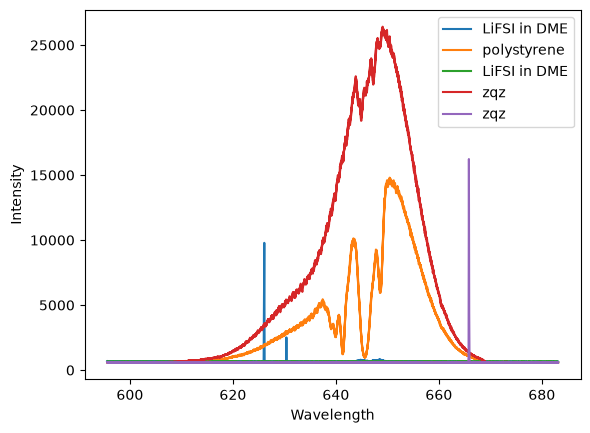

In [6]:
for f in files:
    plt.plot(
        f.data["Wavelength"],
        f.data["Intensity"],
        label=f.metadata["sample"]
        )
    plt.xlabel("Wavelength")
    plt.ylabel("Intensity")

plt.legend()

(600.0, 850.0)

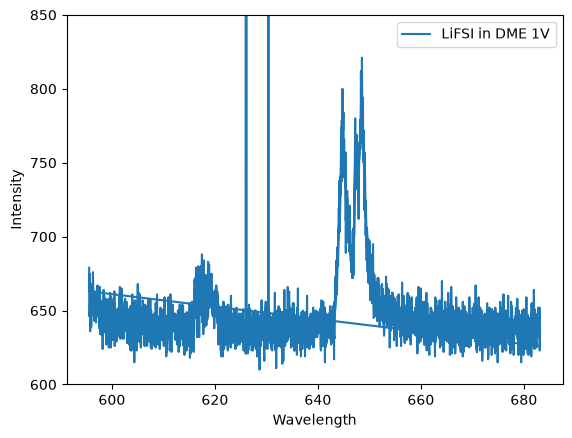

In [7]:
plt.plot(
        f1.data["Wavelength"],
        f1.data["Intensity"],
        label=f"{f1.metadata["sample"]} {f1.metadata["potential"]}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

(600.0, 850.0)

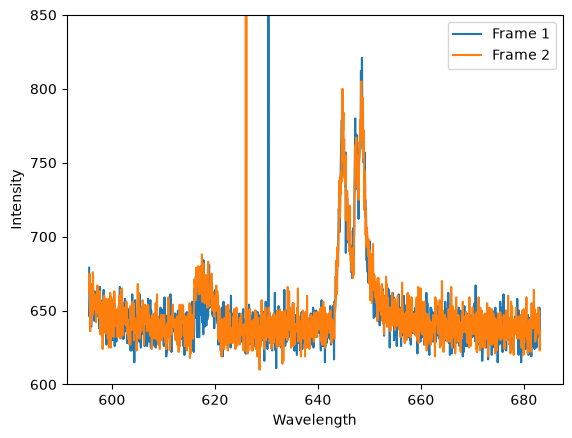

In [8]:
for frame in range(f1.n_frames):
    frame += 1
    plt.plot(
        f1.frame(frame)["Wavelength"],
        f1.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

## Cosmic rays removal and frames averaging

(600.0, 850.0)

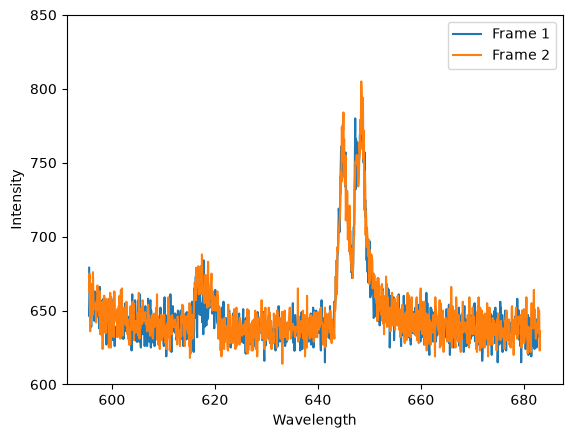

In [9]:
f1_cleaned = f1.remove_cosmic_rays()
for frame in range(f1_cleaned.n_frames):
    frame += 1
    plt.plot(
        f1_cleaned.frame(frame)["Wavelength"],
        f1_cleaned.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

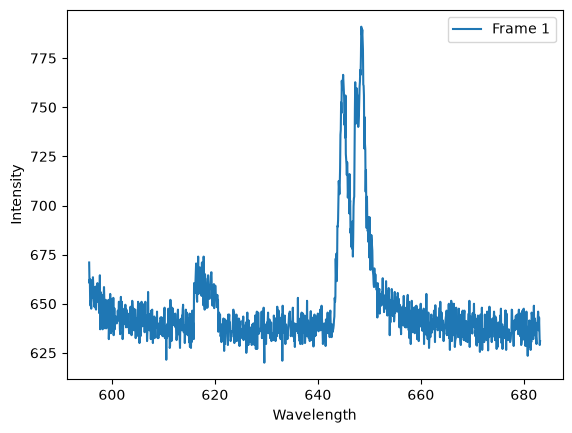

In [10]:
f1_cleaned_averaged = f1.remove_cosmic_rays().average_spectrum()
for frame in range(f1_cleaned_averaged.n_frames):
    frame += 1
    plt.plot(
        f1_cleaned_averaged.frame(frame)["Wavelength"],
        f1_cleaned_averaged.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()

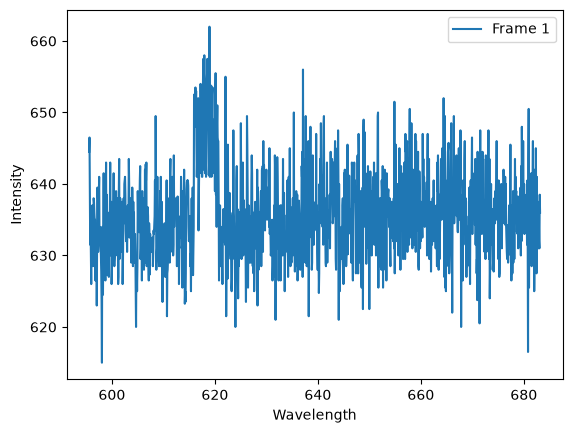

In [11]:
f3_cleaned_averaged = f3.remove_cosmic_rays().average_spectrum()
for frame in range(f3_cleaned_averaged.n_frames):
    frame += 1
    plt.plot(
        f3_cleaned_averaged.frame(frame)["Wavelength"],
        f3_cleaned_averaged.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()

## Background subtraction

Text(0, 0.5, 'Intensity')

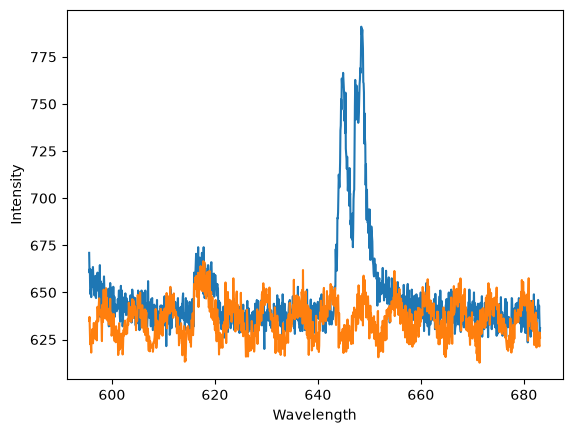

In [12]:
bg = apply_offset(f3.remove_cosmic_rays().average_spectrum(), offset=lambda w: 10 * np.sin(w))
plt.plot(f1.remove_cosmic_rays().average_spectrum().data["Wavelength"], f1.remove_cosmic_rays().average_spectrum().data["Intensity"])
plt.plot(bg.data["Wavelength"], bg.data["Intensity"])
plt.xlabel("Wavelength")
plt.ylabel("Intensity")

Text(0, 0.5, 'Intensity')

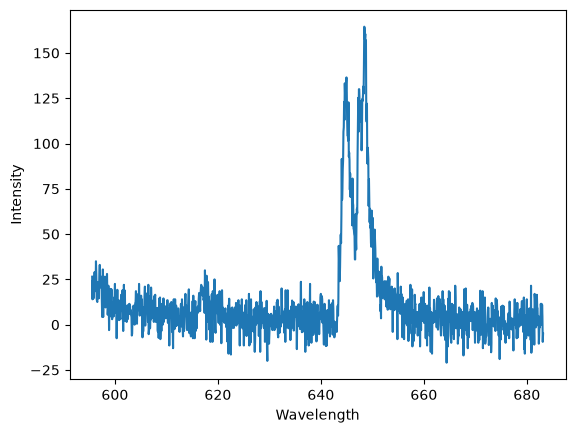

In [13]:
sample = subtract_background(
    f1.remove_cosmic_rays().average_spectrum(),
    f3.remove_cosmic_rays().average_spectrum()
    )

plt.plot(sample.data["Wavelength"], sample.data["Intensity"])
plt.xlabel("Wavelength")
plt.ylabel("Intensity")

## Normalization

C:\Users\silan\Desktop\Research\programming\SFG-app2\SFG-App2\src\sfg_app2\processing\normalization.py:31: RuntimeWarning: divide by zero encountered in divide
  normalized_intensity = sample_avg["Intensity"].to_numpy() / ref_lookup.loc[sample_wavelength].to_numpy()
Sample spectrum has not been background-subtracted (history=['remove_cosmic_rays', 'average_spectrum']). Normalizing un-subtracted data is usually not physically meaningful.
Reference spectrum has not been background-subtracted (history=['remove_cosmic_rays', 'average_spectrum']). Normalizing un-subtracted data is usually not physically meaningful.


(635.0, 660.0)

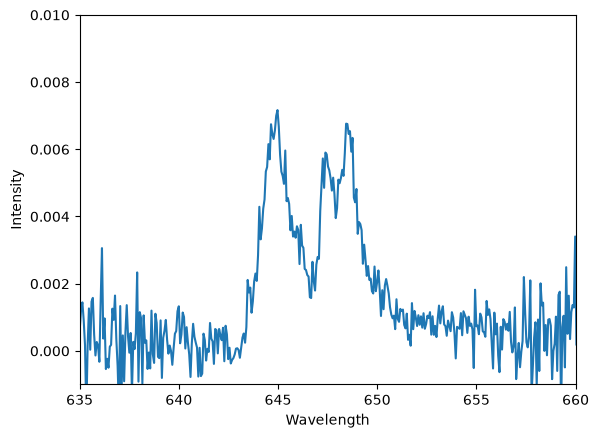

In [14]:
sample = subtract_background(
    f1.remove_cosmic_rays().average_spectrum(),
    f3.remove_cosmic_rays().average_spectrum()
    )
reference = subtract_background(
    f4.remove_cosmic_rays().average_spectrum(),
    f5.remove_cosmic_rays().average_spectrum()
    )

sample_normalized = normalize(sample, reference)
fail_test = normalize(
    f1.remove_cosmic_rays().average_spectrum(),
    f4.remove_cosmic_rays().average_spectrum()
    )


plt.plot(sample_normalized.data["Wavelength"], sample_normalized.data["Intensity"])
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.ylim(-0.001, 0.01)
plt.xlim(635, 660)

## Wavelength upconversion

(2700.0, 3100.0)

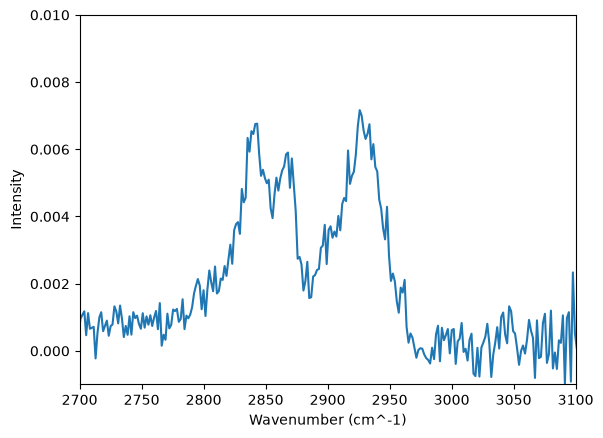

In [15]:
sample = subtract_background(
    f1.remove_cosmic_rays().average_spectrum(),
    f3.remove_cosmic_rays().average_spectrum()
    )
reference = subtract_background(
    f4.remove_cosmic_rays().average_spectrum(),
    f5.remove_cosmic_rays().average_spectrum()
    )

sample_normalized = normalize(sample, reference)
sample_normalized_upconverted = sample_normalized.upconvert_to_wavenumber(795)


plt.plot(
    sample_normalized_upconverted.data["Wavenumber"],
    sample_normalized_upconverted.data["Intensity"]
    )
plt.xlabel("Wavenumber (cm^-1)")
plt.ylabel("Intensity")
plt.ylim(-0.001, 0.01)
plt.xlim(2700, 3100)

## Auto-match datafiles

### Simple loader for datafiles

In [16]:
from sfg_app2.processing.matcher import DataFileMatcher
from sfg_app2.processing.utils import load_datafiles

files = load_datafiles(
    "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_09/simon/csv files",
    patterns=[
        ['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'],
        ['sample', 'concentration', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'],
        ['sample', 'concentration', 'potential', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'],
        ['sample', 'concentration', 'potential', 'interface','polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date']
    ],
)

print(f"Loaded {len(files)} files:")
idx = 0
for f in files:
    print(f"[{idx}] {f}")
    idx += 1

Loaded 31 files:
[0] DataFile(LiFSI in DME_HCE_0.1V_ppp_3.3um_60s_1847_20260609.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_HCE_0.1V_ppp_3.3um_60s_1847_20260609.csv', 'sample': 'LiFSI in DME', 'concentration': 'HCE', 'potential': '0.1V', 'polarization': 'ppp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1847', 'date': '20260609'})
[1] DataFile(LiFSI in DME_HCE_0.1V_ssp_3.3um_60s_1844_20260609.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_HCE_0.1V_ssp_3.3um_60s_1844_20260609.csv', 'sample': 'LiFSI in DME', 'concentration': 'HCE', 'potential': '0.1V', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1844', 'date': '20260609'})
[2] DataFile(LiFSI in DME_HCE_0.25V_ppp_3.3um_60s_1838_20260609.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_HCE_0.25V_ppp_3.3um_60s_1838_20260609.csv', 'sample': 'LiFSI in DME', 'concentration': 'HCE', 'potential': '0.25V', 'polarization': 'ppp', 'c

### Matching loaded files

In [17]:
from sfg_app2.processing.matcher import DataFileMatcher, MatchingConfig

matcher = DataFileMatcher(
    files,
    reference_names=["zqz", "quartz"],
    background_config=MatchingConfig(
        required_keys=["sample", "polarization", "date", "center wavelength"],
        optional_keys=["acquisition time", "concentration"],
    ),
    reference_config=MatchingConfig(
        required_keys=["polarization", "date", "center wavelength"],
        optional_keys=[],
    ),
)

matched = matcher.match()

incomplete = [(i, m) for i, m in enumerate(matched) if not m.is_complete()]
# see what's missing
for i, m in incomplete:
    print(f"[{i}] {m}")

# correct the missing field
matched[20] = matched[20].with_background(files[27]) 

for m in matched:
    print(m)

No background match found for polystyrene_ssp_3.3um_10s_1018_20260609.csv. Use .with_background() to set one manually.


[20] MatchedSet(
  signal             = polystyrene_ssp_3.3um_10s_1018_20260609.csv
  background         = None
  reference          = zqz_ssp_3.3um_10s_1016_20260609.csv
  reference_background = zqz_ssp_3.3um_10s_1017_20260609_bg.csv
)
MatchedSet(
  signal             = LiFSI in DME_HCE_0.1V_ppp_3.3um_60s_1847_20260609.csv
  background         = LiFSI in DME_HCE_2V_ppp_3.3um_60s_1306_20260609_bg.csv
  reference          = zqz_ppp_3.3um_10s_1931_20260609.csv
  reference_background = zqz_ppp_3.3um_10s_1932_20260609_bg.csv
)
MatchedSet(
  signal             = LiFSI in DME_HCE_0.1V_ssp_3.3um_60s_1844_20260609.csv
  background         = LiFSI in DME_HCE_OCP_ssp_3.3um_60s_1040_20260609_bg.csv
  reference          = zqz_ssp_3.3um_10s_1929_20260609.csv
  reference_background = zqz_ssp_3.3um_10s_1930_20260609_bg.csv
)
MatchedSet(
  signal             = LiFSI in DME_HCE_0.25V_ppp_3.3um_60s_1838_20260609.csv
  background         = LiFSI in DME_HCE_2V_ppp_3.3um_60s_1306_20260609_bg.csv
  referenc

### Process matched files

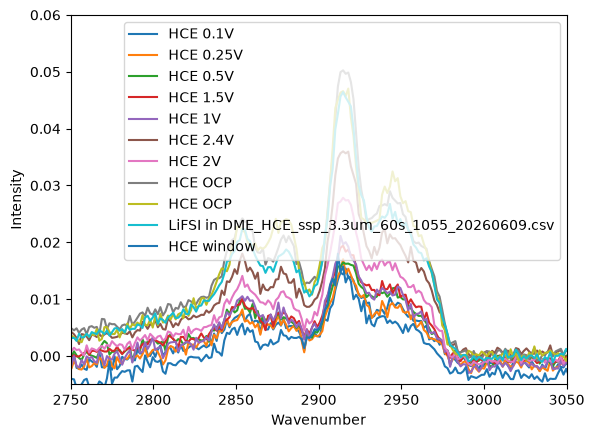

In [53]:
from sfg_app2.processing.pipeline import PipelineConfig, process_batch

# default config shared by most files
default_config = PipelineConfig(
    despike_window=5,
    despike_threshold=3.0,
    upconversion_wavelength=794.3,
)

# # per-file overrides — only files that differ from the default
# per_file_configs = {
#     "sample_ssp_2024-01-15.csv": PipelineConfig(
#         despike_window=7,               # noisier file, wider window
#         despike_threshold=2.5,
#         bg_offset=[0.002, 1.0],         # linear offset needed
#         upconversion_wavelength=794.3,
#     ),
#     "sample_ppp_2024-01-15.csv": PipelineConfig(
#         run_normalize=False,            # no reference available
#         upconversion_wavelength=794.3,
#     ),
# }

results = process_batch(matched, default_config)#, per_file_configs)

# remove polystyrene reference from the results for plotting
results.pop("polystyrene_ssp_3.3um_10s_1018_20260609.csv", None)

fig, ax = plt.subplots()
for filename, spectrum in results.items():
    try:
        label = spectrum.metadata["concentration"] + " " + spectrum.metadata["potential"]
    except KeyError:
        label = filename

    if "ssp" in filename.lower():
        spectrum.plot(
            ax = ax,
            x="Wavenumber",
            label=label
            )

ax.set_xlim(2750, 3050)
ax.set_ylim(-0.005, 0.06)
ax.legend()

## Calibrating upconversion wavelength

C:\Users\silan\AppData\Local\Temp\ipykernel_5220\2254142028.py:24: RuntimeWarning: divide by zero encountered in divide
  ratio = ref_intensity / ps_intensity


(-10.0, 80.0)

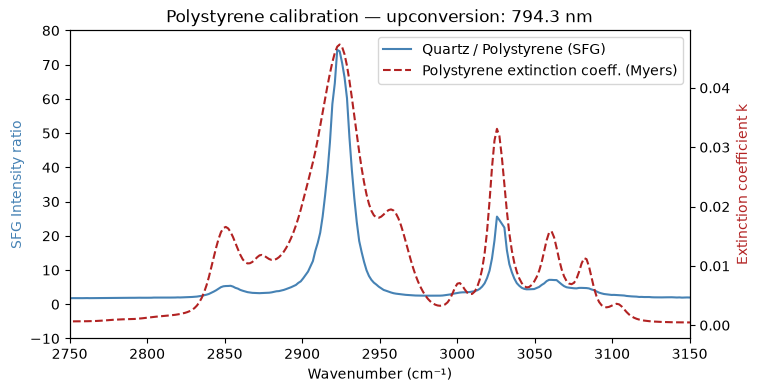

In [50]:
from refractiveindex import RefractiveIndexMaterial

# ── Adjust this to align peaks ────────────────────────────────────────────────
UPCONVERSION_WAVELENGTH = 794.3   # nm — change and rerun this cell

# ── Extract polystyrene (signal) and quartz (reference) ───────────────────────
ps_matched = matched[20]

# ── Despike ───────────────────────────────────────────────────────────────────
ps_signal  = ps_matched.signal.remove_cosmic_rays()
ps_bg      = ps_matched.background.remove_cosmic_rays()
ref_signal = ps_matched.reference.remove_cosmic_rays()
ref_bg     = ps_matched.reference_background.remove_cosmic_rays()

# ── Background subtract both ──────────────────────────────────────────────────
ps_corrected  = subtract_background(ps_signal, ps_bg).average_spectrum()
ref_corrected = subtract_background(ref_signal, ref_bg).average_spectrum()

# ── quartz / polystyrene ──────────────────────────────────────────────────────
ps_intensity  = ps_corrected.frame(1)["Intensity"].to_numpy()
ref_intensity = ref_corrected.frame(1)["Intensity"].to_numpy()
wavelength    = ps_corrected.frame(1)["Wavelength"].to_numpy()

ratio = ref_intensity / ps_intensity

ratio_spectrum = ProcessedSpectrum(
    pd.DataFrame({"Frame": 1, "Wavelength": wavelength, "Intensity": ratio}),
    metadata=ps_matched.signal.metadata,
    history=["subtract_background", "quartz_over_polystyrene"],
).upconvert_to_wavenumber(UPCONVERSION_WAVELENGTH)

# ── Polystyrene extinction coefficient from refractiveindex.info ──────────────
wavenumber = ratio_spectrum.frame(1)["Wavenumber"].to_numpy()

polystyrene = RefractiveIndexMaterial(
    shelf='organic', book='polystyrene', page='Myers'
)
ps_ext = polystyrene.get_extinction_coefficient(wavenumber, unit='cm-1')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ratio_spectrum.plot(ax=ax, x="Wavenumber", label="Quartz / Polystyrene (SFG)", color="steelblue")
ax2 = ax.twinx()
ax2.plot(wavenumber, ps_ext, label="Polystyrene extinction coeff. (Myers)", color="firebrick", linestyle="--")

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("SFG Intensity ratio", color="steelblue")
ax2.set_ylabel("Extinction coefficient k", color="firebrick")
ax.set_title(f"Polystyrene calibration — upconversion: {UPCONVERSION_WAVELENGTH} nm")

# combined legend from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.set_xlim(2750, 3150)
ax.set_ylim(-10, 80)


## Load pharos data

In [ ]:
pf1 = DataFile("C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/pharos/2026_07_17/DMSO_5kHz_ssp_3.45um_60s_1444_2026Jul17_homodyne_bg.csv", filename_fields=['sample', 'rep rate', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
pf1

In [ ]:
fail_test = DataFile("C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/pharos/2026_07_17/Pharos_CCS.csv", filename_fields=['sample', 'rep rate', 'polarization', 'center wavelength', 'acquisition time', 'timestamp'])
fail_test